In [13]:
import pandas as pd

df = pd.read_csv('./data/real_estate_clean_v1.csv', encoding='cp949')

df2 = df.copy()

df2['FLR'] = df2['FLR'].fillna(0)
df_org = df2.copy()

C:\Users\gywns\AppData\Local\Temp\ipykernel_30592\864559479.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/real_estate_clean_v1.csv', encoding='cp949')


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     794606 non-null  int64  
 1   CGG_NM     794606 non-null  object 
 2   STDG_CD    794606 non-null  int64  
 3   STDG_NM    794606 non-null  object 
 4   BLDG_NM    741444 non-null  object 
 5   CTRT_DAY   794606 non-null  object 
 6   THING_AMT  794606 non-null  int64  
 7   ARCH_AREA  794606 non-null  float64
 8   LAND_AREA  633666 non-null  float64
 9   FLR        794606 non-null  float64
 10  RGHT_SE    7039 non-null    object 
 11  ARCH_YR    794606 non-null  int64  
 12  BLDG_USG   794606 non-null  object 
 13  DCLR_SE    213700 non-null  object 
 14  CTRT_YEAR  794606 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 90.9+ MB


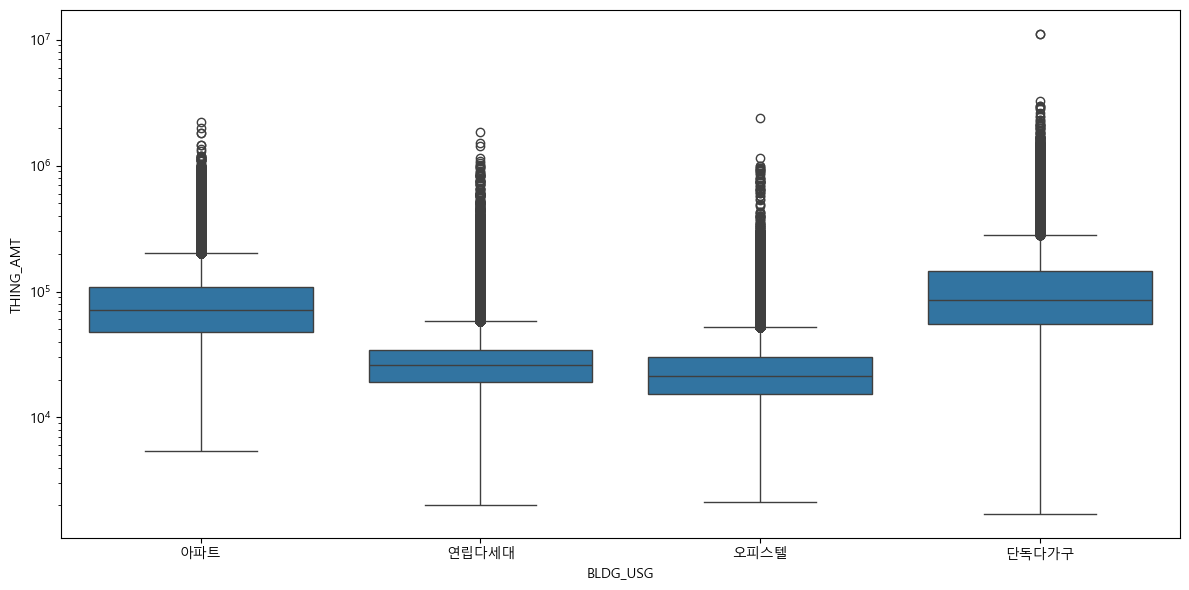

In [16]:
# THING_AMT 이상치/범위 확인
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib import font_manager, rc

# =========================
# 1) 한글 폰트 설정(윈도우 추천)
# =========================

font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

plt.figure(figsize=(12,6))
sns.boxplot(data=df2, x='BLDG_USG', y='THING_AMT')
plt.yscale('log')
plt.tight_layout() 
plt.show()

In [ ]:
# 연립다세대 정의 

df2[df2['BLDG_USG'] == '연립다세대']['FLR'].value_counts().sort_index()

FLR
-3.0         1
-2.0        26
-1.0     20106
 1.0     33038
 2.0     70213
 3.0     61743
 4.0     48671
 5.0     31132
 6.0      9794
 7.0      1940
 8.0      1123
 9.0       703
 10.0      457
 11.0      295
 12.0      188
 13.0      120
 14.0       60
 15.0       36
 16.0       34
 17.0       13
 18.0       15
 19.0        9
 20.0        6
Name: count, dtype: int64

In [28]:
cond1 = df2['BLDG_USG'] == '연립다세대'

yljt2 = df2[cond1].sort_values('FLR', ascending=False)
yljt2.to_csv('./data/yljt2.csv', encoding='cp949', index=False)


In [25]:
df2[df2['BLDG_USG'] == '단독다가구']['FLR'].value_counts().sort_index()

FLR
0.0    53111
Name: count, dtype: int64

In [30]:
df2.head()

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019


In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     794606 non-null  int64  
 1   CGG_NM     794606 non-null  object 
 2   STDG_CD    794606 non-null  int64  
 3   STDG_NM    794606 non-null  object 
 4   BLDG_NM    741444 non-null  object 
 5   CTRT_DAY   794606 non-null  object 
 6   THING_AMT  794606 non-null  int64  
 7   ARCH_AREA  794606 non-null  float64
 8   LAND_AREA  633666 non-null  float64
 9   FLR        794606 non-null  float64
 10  RGHT_SE    7039 non-null    object 
 11  ARCH_YR    794606 non-null  int64  
 12  BLDG_USG   794606 non-null  object 
 13  DCLR_SE    213700 non-null  object 
 14  CTRT_YEAR  794606 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 90.9+ MB


In [32]:
target_usg = ['아파트', '오피스텔', '연립다세대', '단독다가구']

df_plot = df[df['BLDG_USG'].isin(target_usg)].copy()

In [33]:
avg_price = (
    df_plot
    .groupby(['CTRT_YEAR', 'BLDG_USG'])['THING_AMT']
    .mean()
    .reset_index()
)

In [34]:
avg_price

,CTRT_YEAR,BLDG_USG,THING_AMT
0,2018,단독다가구,96262.363226
1,2018,아파트,66118.967683
2,2018,연립다세대,26867.780240
3,2018,오피스텔,25057.813448
4,2019,단독다가구,106655.859623
5,2019,아파트,82192.396326
6,2019,연립다세대,27778.226534
7,2019,오피스텔,25248.238681
8,2020,단독다가구,121303.899982
9,2020,아파트,85096.356581


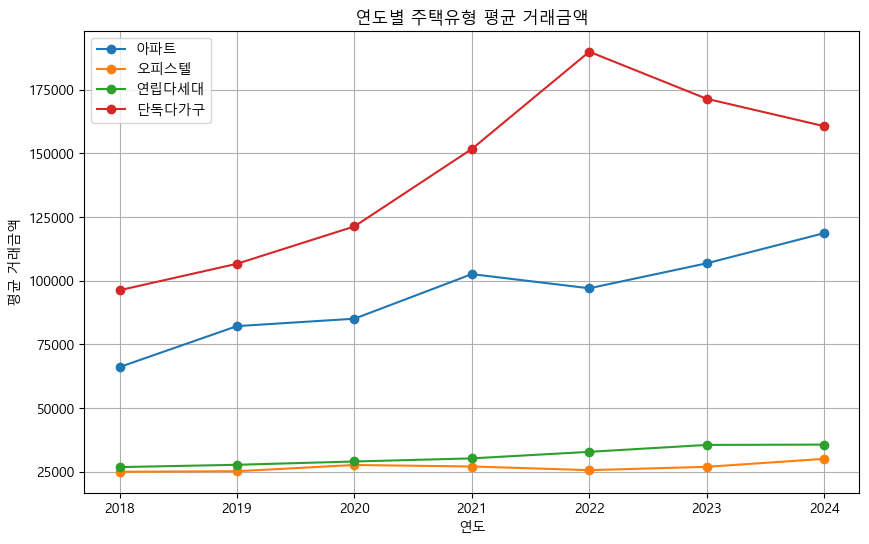

In [37]:
plt.figure(figsize=(10, 6))

for usg in target_usg:
    data = avg_price[avg_price['BLDG_USG'] == usg]
    plt.plot(
        data['CTRT_YEAR'],
        data['THING_AMT'],
        marker='o',
        label=usg
    )

plt.title('연도별 주택유형 평균 거래금액')
plt.xlabel('연도')
plt.ylabel('평균 거래금액')
plt.legend()
plt.grid(True)

plt.show()

단독다가구의 경우 건물을 통째로 거래하는 경우가 많기에 거래 금액이 크다.
아파트와 단독다가구의 경우 매년 거래 평균금액이 증가하는 추세이다. -> 투자를 원한다면 추천해주기 좋을 것 같음
연립다세대와 오피스텔의 경우 연도별로 평균거래금액이 크게 변하지 않았다. -> 안정적인 거주를 위한 고객이 있다면 추천해주기 좋을 것 같음

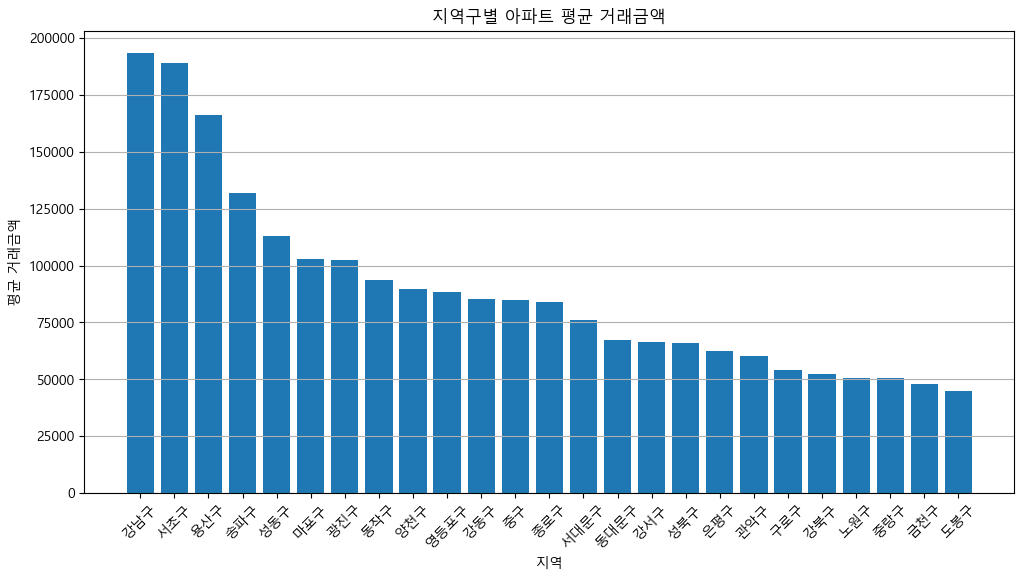

In [45]:
# 아파트만 필터링
apt_df = df[df['BLDG_USG'] == '아파트']

# 지역별 평균 거래금액
region_avg_price = (
    apt_df
    .groupby('CGG_NM')['THING_AMT']
    .mean()
    .reset_index()
    .sort_values(by='THING_AMT', ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    region_avg_price['CGG_NM'],
    region_avg_price['THING_AMT']
)

plt.title('지역구별 아파트 평균 거래금액')
plt.xlabel('지역')
plt.ylabel('평균 거래금액')
plt.xticks(rotation=45)
plt.grid(axis='y')

아파트 평균 거래금액이 큰 순서대로 나열해서 어떤 지역구가 거래금액이 큰지 확인 할 수 있다. 투자를 원하는 고객에게는 강남구, 서초구, 용산구, 송파구, 성동구 매물을 추천해주고 싶은데 연도별로 아파트 가격이 얼마나 다른지 보여주면 좋은 자료가 될 것 같아. -> 그럼 혹시 거래량도 거래금액과 비슷한 순서대로 나올까?

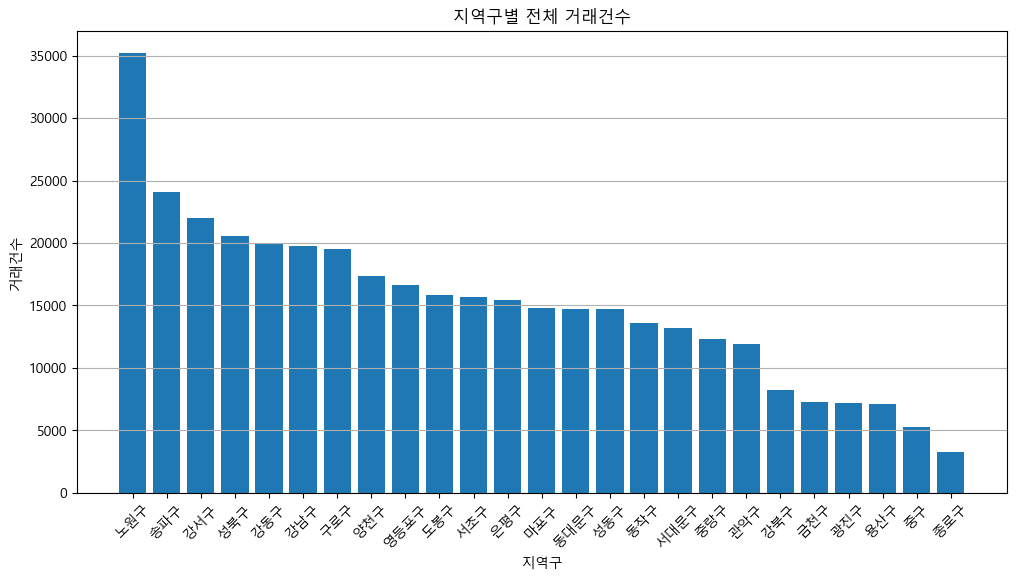

In [52]:
region_trade_cnt = (
    apt_df
    .groupby('CGG_NM')
    .size()
    .reset_index(name='거래건수')
    .sort_values(by='거래건수', ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(
    region_trade_cnt['CGG_NM'],
    region_trade_cnt['거래건수']
)

plt.title('지역구별 전체 거래건수')
plt.xlabel('지역구')
plt.ylabel('거래건수')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

예상과는 다르게 거래금액이 높다고 거래량이 많지는 않게 나오네. 그럼 이 그래프를 보고 빠르게 거래를 원하는 고객들에게는 거래량이 높은 지역구별로 매물을 찾아주면 좋을 것 같아.
그럼 다시 투자를 원하는 고객들을 위해 상위5개 거래금액의 지역구별로 매년 어떻게 다른지 봐보자

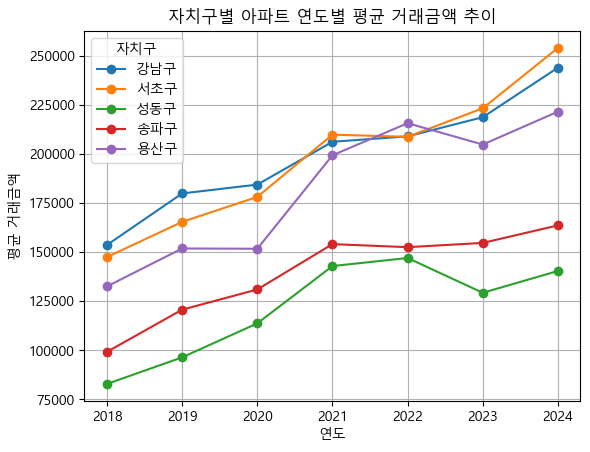

In [55]:
apt_avg = (
    apt_df
    .groupby(['CTRT_YEAR', 'CGG_NM'])['THING_AMT']
    .mean()
    .reset_index()
)

top_gu = (
    apt_df
    .groupby('CGG_NM')['THING_AMT']
    .mean()                # 지역구별 평균 거래금액
    .sort_values(ascending=False)
    .head(5)
    .index
)

apt_avg = apt_avg[apt_avg['CGG_NM'].isin(top_gu)]

for gu in apt_avg['CGG_NM'].unique():
    data = apt_avg[apt_avg['CGG_NM'] == gu]
    plt.plot(
        data['CTRT_YEAR'],
        data['THING_AMT'],
        marker='o',
        label=gu
    )

plt.title('자치구별 아파트 연도별 평균 거래금액 추이')
plt.xlabel('연도')
plt.ylabel('평균 거래금액')
plt.legend(title='자치구')
plt.grid(True)

plt.show()

df2.info()

In [56]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     794606 non-null  int64  
 1   CGG_NM     794606 non-null  object 
 2   STDG_CD    794606 non-null  int64  
 3   STDG_NM    794606 non-null  object 
 4   BLDG_NM    741444 non-null  object 
 5   CTRT_DAY   794606 non-null  object 
 6   THING_AMT  794606 non-null  int64  
 7   ARCH_AREA  794606 non-null  float64
 8   LAND_AREA  633666 non-null  float64
 9   FLR        794606 non-null  float64
 10  RGHT_SE    7039 non-null    object 
 11  ARCH_YR    794606 non-null  int64  
 12  BLDG_USG   794606 non-null  object 
 13  DCLR_SE    213700 non-null  object 
 14  CTRT_YEAR  794606 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 90.9+ MB


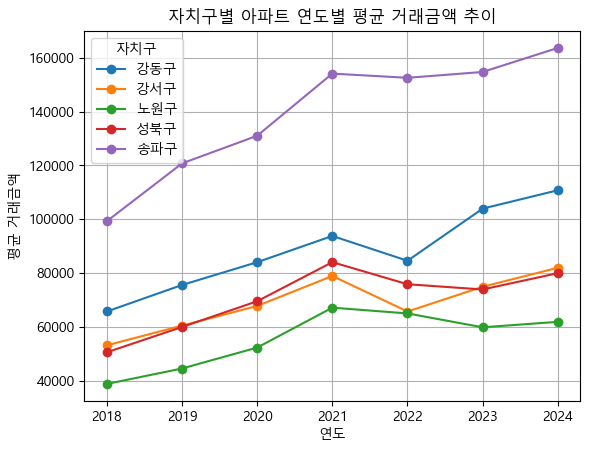

In [53]:
apt_avg = (
    apt_df
    .groupby(['CTRT_YEAR', 'CGG_NM'])['THING_AMT']
    .mean()
    .reset_index()
)

top_gu = (
    apt_df['CGG_NM']
    .value_counts()
    .head(5)
    .index
)

apt_avg = apt_avg[apt_avg['CGG_NM'].isin(top_gu)]

for gu in apt_avg['CGG_NM'].unique():
    data = apt_avg[apt_avg['CGG_NM'] == gu]
    plt.plot(
        data['CTRT_YEAR'],
        data['THING_AMT'],
        marker='o',
        label=gu
    )

plt.title('자치구별 아파트 연도별 평균 거래금액 추이')
plt.xlabel('연도')
plt.ylabel('평균 거래금액')
plt.legend(title='자치구')
plt.grid(True)

plt.show()

거래건수가 많은 상위 5개 지역구의 연도별 거래금액 추이를 확인해봤어.

<class 'pandas.core.frame.DataFrame'>
Index: 279723 entries, 3 to 794603
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     279723 non-null  int64  
 1   CGG_NM     279723 non-null  object 
 2   STDG_CD    279723 non-null  int64  
 3   STDG_NM    279723 non-null  object 
 4   BLDG_NM    279722 non-null  object 
 5   CTRT_DAY   279723 non-null  object 
 6   THING_AMT  279723 non-null  int64  
 7   ARCH_AREA  279723 non-null  float64
 8   LAND_AREA  279723 non-null  float64
 9   FLR        279723 non-null  float64
 10  RGHT_SE    0 non-null       object 
 11  ARCH_YR    279723 non-null  int64  
 12  BLDG_USG   279723 non-null  object 
 13  DCLR_SE    78082 non-null   object 
 14  CTRT_YEAR  279723 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 34.1+ MB


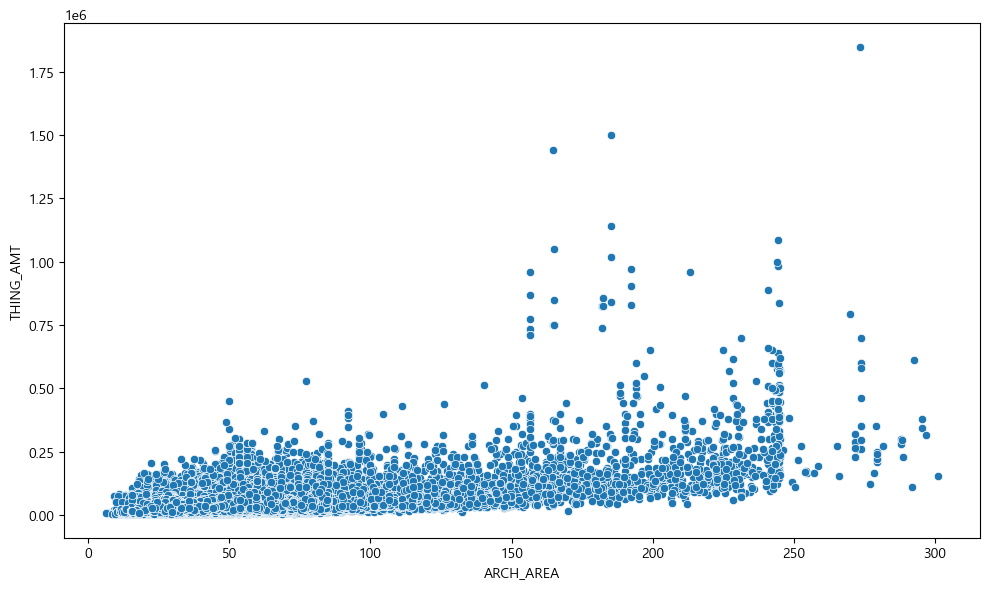

In [29]:
# 연립다세대
df_yljt = df2[df2['BLDG_USG']=='연립다세대']
df_yljt.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_yljt, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

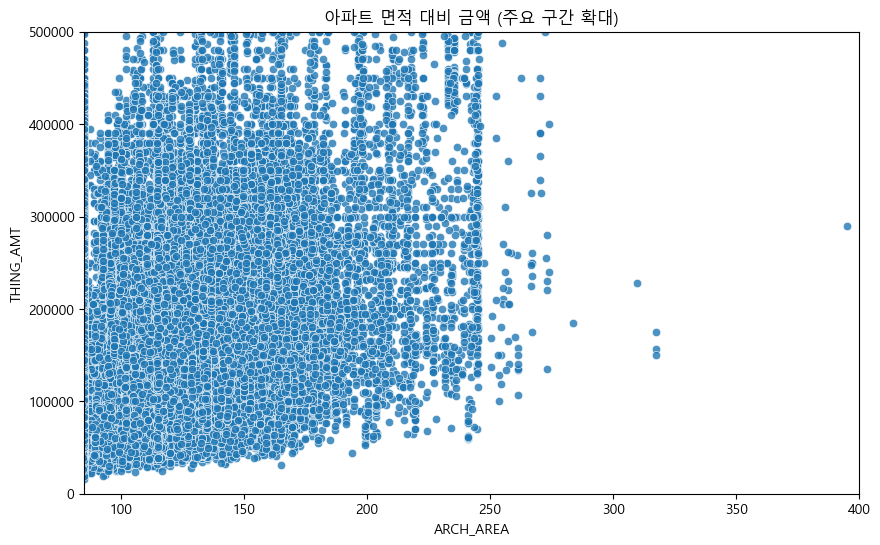

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

area_q3 = apt['ARCH_AREA'].quantile(0.75)
# x축: q3 ~ 400 (건물면적 최댓값이 395)
# y축: 금액 50억(500,000만원) 이하로 제한
plt.xlim(area_q3,400)
plt.ylim(0, 0.5e+06)

plt.title('아파트 면적 대비 금액 (주요 구간 확대)')
plt.show()

In [14]:
# 건물가격 비율 분포 확인 
plt.figure(figsize=(10,5))
plt.hist(df_org['물건금액(만원)'], bins = 1000)
plt.xlabel('물건금액(만원)')
plt.ylabel('count')
plt.xlim(0,0.1e+07)
plt.tight_layout() 
plt.show()

KeyError: '물건금액(만원)'

<Figure size 1000x500 with 0 Axes>